In [1]:
%load_ext autoreload
%autoreload 2

import os
os.chdir("..")  # go to project root
print(f"cwd: {os.getcwd()}")  # sanity check

cwd: /home/dude-desktop/dev/taming-transformers


In [67]:
import pandas as pd
import numpy as np
import csv
from PIL import Image, ImageDraw, ImageFont
import json
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
RESULTS_CSV = "analysis/results.csv"
FIG_DIR = "analysis/figs"
STANDARD_COLS = [
    "run_name",
    "mIoU_macro",
    "f1_macro",
    "precision_macro",
    "recall_macro",
    "accuracy_macro",
]

def table_3sf(df):
    return df.round(3)

In [4]:
R = pd.read_csv(RESULTS_CSV, quoting=csv.QUOTE_NONNUMERIC)
R

,run_name,ckpt_path,mIoU_macro,accuracy_macro,f1_macro,precision_macro,recall_macro,acc_unlabeled,acc_person,acc_bicycle,...,acc_wall-other,acc_wall-panel,acc_wall-stone,acc_wall-tile,acc_wall-wood,acc_water-other,acc_waterdrops,acc_window-blind,acc_window-other,acc_wood
0,coco_segmentation_ce_loss,analysis/logs/2025-10-01T12-17-48_coco_segment...,0.738424,0.790192,0.816147,0.857616,0.790192,0.893240,0.975127,0.823268,...,0.954025,0.935865,0.910334,0.973672,0.945284,0.963484,0.398698,0.929140,0.957342,0.928822
1,coco_segmentation_bce_loss,analysis/logs/2025-10-01T12-18-14_coco_segment...,0.723861,0.778291,0.803212,0.847983,0.778291,0.904578,0.975154,0.804283,...,0.949198,0.936621,0.914283,0.971289,0.940921,0.951587,0.304488,0.911938,0.961856,0.897355
2,coco_segmentation_ce_dice_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.748511,0.802365,0.825784,0.860769,0.802365,0.901436,0.960015,0.815714,...,0.952559,0.937452,0.933217,0.958994,0.946226,0.956061,0.434010,0.936973,0.947774,0.863489
3,coco_segmentation_focal_g1_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.723710,0.781435,0.805785,0.849064,0.781435,0.885957,0.951253,0.740170,...,0.942871,0.927907,0.930618,0.964017,0.933229,0.949031,0.227377,0.919797,0.923135,0.875373
4,coco_segmentation_focal_g2_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.729700,0.782227,0.808846,0.856277,0.782227,0.882653,0.973313,0.811503,...,0.959985,0.881252,0.871911,0.968499,0.942610,0.962642,0.203984,0.931301,0.951433,0.903157
5,coco_segmentation_focal_g5_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.672012,0.743484,0.769479,0.822827,0.743484,0.498375,0.945617,0.790519,...,0.831414,0.934894,0.904133,0.909554,0.865991,0.917739,0.249256,0.933615,0.945582,0.826733
6,coco_segmentation_focal_g2_acw_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.509513,0.567434,0.604220,0.703344,0.567434,0.914636,0.982492,0.532875,...,0.917045,0.751498,0.756156,0.915747,0.832701,0.916752,0.000000,0.731019,0.847093,0.576458
7,coco_segmentation_focal_g2_log_acw_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.722990,0.769199,0.802064,0.863473,0.769199,0.903230,0.972375,0.786884,...,0.968748,0.935963,0.916664,0.974679,0.948059,0.961934,0.217781,0.923084,0.952551,0.875939
8,coco_segmentation_ce_lovasz_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.727159,0.785056,0.809466,0.849768,0.785056,0.876999,0.961460,0.820427,...,0.925251,0.945789,0.912521,0.921624,0.928513,0.962783,0.350349,0.920397,0.950563,0.877120
9,coco_segmentation_logcoshdice_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.676024,0.738313,0.763039,0.804276,0.738313,0.739182,0.885531,0.810527,...,0.846476,0.864721,0.872722,0.898958,0.893461,0.906667,0.055232,0.909636,0.914230,0.889351


### Focal: Best $\gamma$ (gamma)

In [5]:
FOCAL_GAMMA_EXPERIMENTS = [
    "coco_segmentation_focal_g1_loss",
    "coco_segmentation_focal_g2_loss",
    "coco_segmentation_focal_g5_loss",
]

R_focal_gamma = R[R["run_name"].isin(FOCAL_GAMMA_EXPERIMENTS)]
display(R_focal_gamma[STANDARD_COLS])
table_3sf(R_focal_gamma[STANDARD_COLS])

,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
3,coco_segmentation_focal_g1_loss,0.723710,0.805785,0.849064,0.781435,0.781435
4,coco_segmentation_focal_g2_loss,0.729700,0.808846,0.856277,0.782227,0.782227
5,coco_segmentation_focal_g5_loss,0.672012,0.769479,0.822827,0.743484,0.743484


,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
3,coco_segmentation_focal_g1_loss,0.724,0.806,0.849,0.781,0.781
4,coco_segmentation_focal_g2_loss,0.730,0.809,0.856,0.782,0.782
5,coco_segmentation_focal_g5_loss,0.672,0.769,0.823,0.743,0.743


### Focal: Best $\alpha$ (alpha)

In [6]:
FOCAL_ALPHA_EXPERIMENTS = [
    "coco_segmentation_focal_g2_acw_loss",
    "coco_segmentation_focal_g2_log_acw_loss",
]

R_focal_alpha = R[R["run_name"].isin(FOCAL_ALPHA_EXPERIMENTS)]
display(R_focal_alpha[STANDARD_COLS])
table_3sf(R_focal_alpha[STANDARD_COLS])

,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
6,coco_segmentation_focal_g2_acw_loss,0.509513,0.604220,0.703344,0.567434,0.567434
7,coco_segmentation_focal_g2_log_acw_loss,0.722990,0.802064,0.863473,0.769199,0.769199


,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
6,coco_segmentation_focal_g2_acw_loss,0.510,0.604,0.703,0.567,0.567
7,coco_segmentation_focal_g2_log_acw_loss,0.723,0.802,0.863,0.769,0.769


### Overall Performance Comparison

In [54]:
OVERALL_EXPERIMENTS = set(R["run_name"].unique()) - set(FOCAL_GAMMA_EXPERIMENTS) - set(FOCAL_ALPHA_EXPERIMENTS) | {"coco_segmentation_focal_g2_loss"}
R_overall = R[R["run_name"].isin(OVERALL_EXPERIMENTS)]
display(R_overall[STANDARD_COLS])
table_3sf(R_overall[STANDARD_COLS])

,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
0,coco_segmentation_ce_loss,0.738424,0.816147,0.857616,0.790192,0.790192
1,coco_segmentation_bce_loss,0.723861,0.803212,0.847983,0.778291,0.778291
2,coco_segmentation_ce_dice_loss,0.748511,0.825784,0.860769,0.802365,0.802365
4,coco_segmentation_focal_g2_loss,0.729700,0.808846,0.856277,0.782227,0.782227
8,coco_segmentation_ce_lovasz_loss,0.727159,0.809466,0.849768,0.785056,0.785056
9,coco_segmentation_logcoshdice_loss,0.676024,0.763039,0.804276,0.738313,0.738313


,run_name,mIoU_macro,f1_macro,precision_macro,recall_macro,accuracy_macro
0,coco_segmentation_ce_loss,0.738,0.816,0.858,0.790,0.790
1,coco_segmentation_bce_loss,0.724,0.803,0.848,0.778,0.778
2,coco_segmentation_ce_dice_loss,0.749,0.826,0.861,0.802,0.802
4,coco_segmentation_focal_g2_loss,0.730,0.809,0.856,0.782,0.782
8,coco_segmentation_ce_lovasz_loss,0.727,0.809,0.850,0.785,0.785
9,coco_segmentation_logcoshdice_loss,0.676,0.763,0.804,0.738,0.738


### Overall mean IoU bar chart

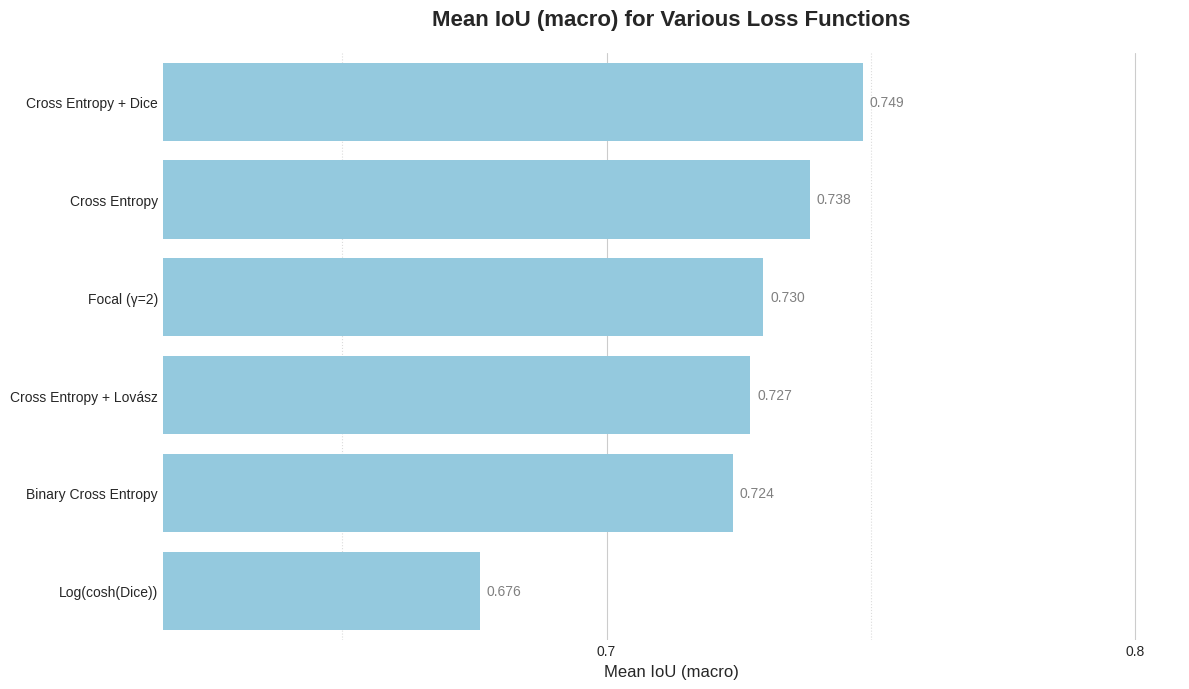

,run_name,ckpt_path,mIoU_macro,accuracy_macro,f1_macro,precision_macro,recall_macro,acc_unlabeled,acc_person,acc_bicycle,...,acc_wall-other,acc_wall-panel,acc_wall-stone,acc_wall-tile,acc_wall-wood,acc_water-other,acc_waterdrops,acc_window-blind,acc_window-other,acc_wood
0,coco_segmentation_ce_loss,analysis/logs/2025-10-01T12-17-48_coco_segment...,0.738424,0.790192,0.816147,0.857616,0.790192,0.893240,0.975127,0.823268,...,0.954025,0.935865,0.910334,0.973672,0.945284,0.963484,0.398698,0.929140,0.957342,0.928822
1,coco_segmentation_bce_loss,analysis/logs/2025-10-01T12-18-14_coco_segment...,0.723861,0.778291,0.803212,0.847983,0.778291,0.904578,0.975154,0.804283,...,0.949198,0.936621,0.914283,0.971289,0.940921,0.951587,0.304488,0.911938,0.961856,0.897355
2,coco_segmentation_ce_dice_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.748511,0.802365,0.825784,0.860769,0.802365,0.901436,0.960015,0.815714,...,0.952559,0.937452,0.933217,0.958994,0.946226,0.956061,0.434010,0.936973,0.947774,0.863489
4,coco_segmentation_focal_g2_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.729700,0.782227,0.808846,0.856277,0.782227,0.882653,0.973313,0.811503,...,0.959985,0.881252,0.871911,0.968499,0.942610,0.962642,0.203984,0.931301,0.951433,0.903157
8,coco_segmentation_ce_lovasz_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.727159,0.785056,0.809466,0.849768,0.785056,0.876999,0.961460,0.820427,...,0.925251,0.945789,0.912521,0.921624,0.928513,0.962783,0.350349,0.920397,0.950563,0.877120
9,coco_segmentation_logcoshdice_loss,/home/dude-desktop/dev/taming-transformers/ana...,0.676024,0.738313,0.763039,0.804276,0.738313,0.739182,0.885531,0.810527,...,0.846476,0.864721,0.872722,0.898958,0.893461,0.906667,0.055232,0.909636,0.914230,0.889351


In [ ]:
HUMAN_READABLE_NAMES = {
    "coco_segmentation_ce_loss": "Cross Entropy",
    "coco_segmentation_bce_loss": "Binary Cross Entropy",
    "coco_segmentation_ce_dice_loss": "Cross Entropy + Dice",
    "coco_segmentation_focal_g2_loss": "Focal (γ=2)",
    "coco_segmentation_ce_lovasz_loss": "Cross Entropy + Lovász",
    "coco_segmentation_logcoshdice_loss": "Log(cosh(Dice))",
    "coco_segmentation_ce_focal_tversky_loss": "Cross Entropy + Focal Tversky",
}

import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as mticker

def plot_mean_iou_bar_chart(df, title, save_path):
    df = df.copy()
    df["run_name"] = df["run_name"].map(HUMAN_READABLE_NAMES).fillna(df["run_name"])
    # sort by mIoU_macro descending
    df = df.sort_values(by="mIoU_macro", ascending=False)

    # Set a professional plot style
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 7))

    # Create the horizontal bar plot
    bars = sns.barplot(
        x="mIoU_macro",
        y="run_name",
        data=df,
        color='skyblue',
        ax=ax
    )

    # Add data labels to each bar for precise values
    ax.bar_label(bars.containers[0], fmt='%.3f', padding=5, fontsize=10, color='gray')

    # --- Grid and Axis Customization ---
    # Set major grid lines every 0.1 and minor ones every 0.05
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax.xaxis.set_minor_locator(mticker.MultipleLocator(0.05))
    ax.grid(which='minor', axis='x', linestyle=':', alpha=0.7)

    # Set plot limits and labels
    ax.set_xlim(left=min(df["mIoU_macro"]) - 0.06, right=max(df["mIoU_macro"]) + 0.06) # Auto-adjust x-limits
    # ax.set_xlim(left=0.695, right=0.805) # Auto-adjust x-limits
    ax.set_title(title, fontsize=16, pad=20, weight='bold')
    ax.set_xlabel('Mean IoU (macro)', fontsize=12)
    ax.set_ylabel('') # The y-ticks are self-explanatory

    # Remove unnecessary chart borders (spines)
    sns.despine(left=True, bottom=True)
    
    # --- Final Touches ---
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_mean_iou_bar_chart(R_overall, "Mean IoU (macro) for Various Loss Functions", os.path.join(FIG_DIR, "mean_iou_bar_chart.png"))

### Qualitative Comparison

In [9]:
from main import instantiate_from_config, DataModuleFromConfig
from omegaconf import OmegaConf
import torch
import torch.nn.functional as F
import random
from taming.models.vqgan import VQSegmentationModel

In [10]:
DATA_CONFIG = """
target: main.DataModuleFromConfig
params:
    num_workers: 0
    batch_size: 8
    train:
      target: taming.data.coco.CocoImagesAndCaptionsTrain
      params:
        size: 296
        crop_size: 256
        onehot_segmentation: true
        use_stuffthing: true
    validation:
      target: taming.data.coco.CocoImagesAndCaptionsValidation
      params:
        size: 256
        crop_size: 256
        onehot_segmentation: true
        use_stuffthing: true
"""

data_cfg = OmegaConf.create(DATA_CONFIG)
data: DataModuleFromConfig = instantiate_from_config(data_cfg)
data.prepare_data()
data.setup()
train_ldr = data.train_dataloader()
val_ldr = data.val_dataloader()

ImgToCaptions: 100%|██████████| 25014/25014 [00:00<00:00, 1370720.53it/s]


In [11]:
with open("data/cocostuffthings/labels.txt", "r") as f:
    labels = [line.strip().split(": ")[1] for line in f.readlines()]
print(labels)

['unlabeled', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'street sign', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'hat', 'backpack', 'umbrella', 'shoe', 'eye glasses', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'plate', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'mirror', 'dining table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'blender', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush', 'hair brush', 'banner', 

In [ ]:
def load_model_from_ckpt(ckpt_path, model):
    sd = torch.load(ckpt_path, map_location="cpu")["state_dict"]
    missing, unexpected = model.load_state_dict(sd, strict=False)
    model.cuda().eval()
    torch.set_grad_enabled(False)
    return model

MODEL_CONFIG = """
embed_dim: 256
n_embed: 1024
image_key: "segmentation"
n_labels: 183
ddconfig:
  double_z: false
  z_channels: 256
  resolution: 256
  in_channels: 183
  out_ch: 183
  ch: 128
  ch_mult:
  - 1
  - 1
  - 2
  - 2
  - 4
  num_res_blocks: 2
  attn_resolutions:
  - 16
  dropout: 0.0

lossconfig:
  target: taming.modules.losses.DummyLoss
"""
model_cfg = OmegaConf.create(MODEL_CONFIG)
model = VQSegmentationModel(**model_cfg)
model = load_model_from_ckpt(R_overall.iloc[0]["ckpt_path"], model)
colorize_buf = model.colorize

Working with z of shape (1, 256, 16, 16) = 65536 dimensions.
tensor([[[[ 3.5456e-01]],

         [[ 1.5772e+00]],

         [[ 3.8692e-01]],

         [[ 7.3395e-02]],

         [[-5.9858e-02]],

         [[-2.2960e-01]],

         [[-8.4084e-01]],

         [[-1.2058e+00]],

         [[ 4.5366e-01]],

         [[-1.1489e+00]],

         [[-1.1832e+00]],

         [[ 1.8413e-01]],

         [[-1.3400e+00]],

         [[ 5.6139e-01]],

         [[ 1.7062e-01]],

         [[-1.8773e+00]],

         [[-2.9538e-01]],

         [[-7.2751e-01]],

         [[-1.9940e-01]],

         [[-1.8740e+00]],

         [[-4.4443e-01]],

         [[-8.1884e-02]],

         [[ 8.2168e-01]],

         [[ 2.5348e-01]],

         [[ 9.1670e-01]],

         [[ 6.0453e-01]],

         [[ 1.7917e-01]],

         [[ 8.3580e-02]],

         [[ 4.9788e-01]],

         [[ 1.8798e+00]],

         [[-4.3028e-02]],

         [[-4.9975e-01]],

         [[-8.0722e-02]],

         [[-3.2880e-01]],

         [[-8.2288e-0

Processing Cross Entropy + Dice...
Processing Cross Entropy...
Processing Focal (γ=2)...
Processing Cross Entropy + Lovász...
Processing Binary Cross Entropy...
Processing Log(cosh(Dice))...


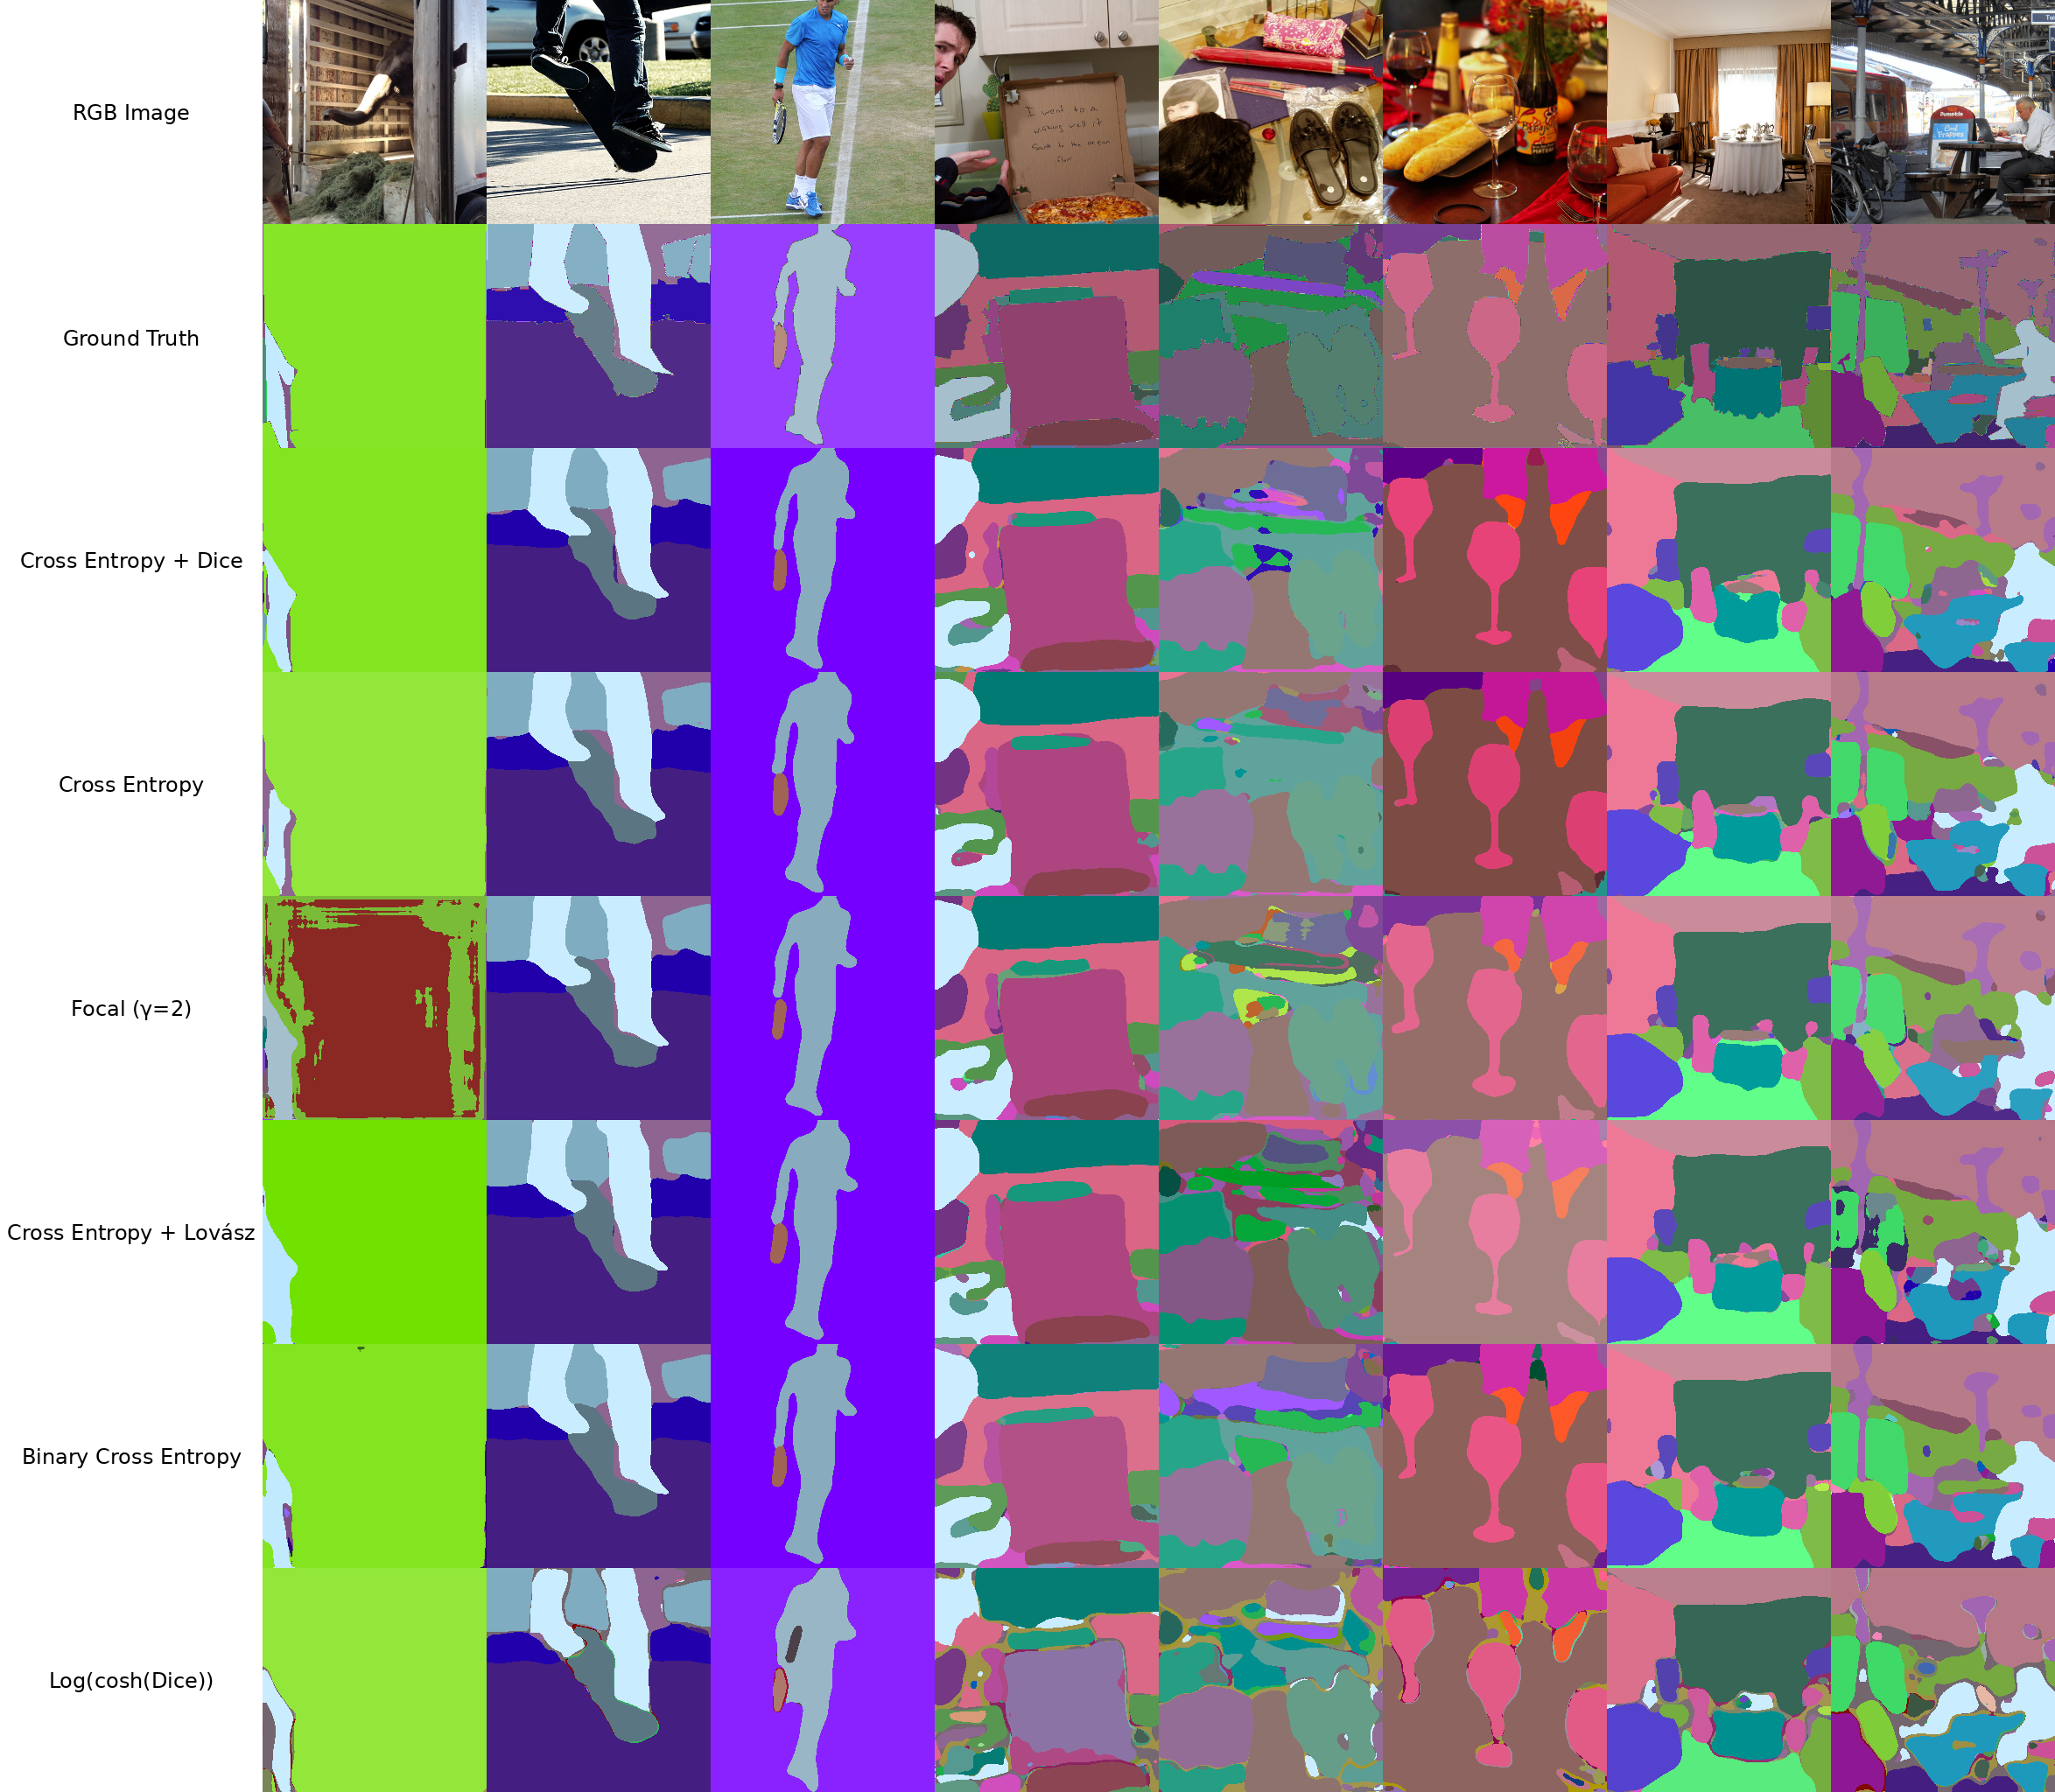

In [57]:
def show_segmentation(s, show=True):
    model.colorize = colorize_buf.clone()
    s = model.to_rgb(s)
    s = ((s+1.0)*127.5).clip(0,255).to(torch.uint8)
    s = s.detach().cpu().numpy().transpose(0, 2, 3, 1)[0]
    s = Image.fromarray(s)
    if show:
        display(s)
    else:
        return s
    
def combine_images_side_by_side(images):
    # Calculate total width and max height
    total_width = sum(img.width for img in images)
    max_height = max(img.height for img in images)

    # Create a new blank image
    combined = Image.new("RGB", (total_width, max_height))

    # Paste each image next to each other
    x_offset = 0
    for img in images:
        combined.paste(img, (x_offset, 0))
        x_offset += img.width

    return combined

def combine_images_top_to_bottom(images):
    # Calculate max width and total height
    max_width = max(img.width for img in images)
    total_height = sum(img.height for img in images)

    # Create a new blank image
    combined = Image.new("RGB", (max_width, total_height))

    # Paste each image on top of each other
    y_offset = 0
    for img in images:
        combined.paste(img, (0, y_offset))
        y_offset += img.height

    return combined

def reconstruct(model, s):
    segmentation_rec, _ = model(s)
    segmentation_rec = torch.argmax(segmentation_rec, dim=1, keepdim=True)
    segmentation_rec = F.one_hot(segmentation_rec, num_classes=s.shape[1])
    segmentation_rec = segmentation_rec.squeeze(1).permute(0,3,1,2).to(torch.float32)
    return segmentation_rec

def add_text_to_image(image, text, text_width=300, font_size=24):
    try:
        # Use a common font like Arial; adjust the path if needed
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", font_size)
    except IOError:
        # Fallback to a default font if the specified one isn't found
        print("Arial font not found. Using default font.")
        font = ImageFont.load_default(size=font_size)

    # Create a new blank image with extra width for the text
    new_width = text_width + image.width
    new_image = Image.new("RGB", (new_width, image.height), "white")
    draw = ImageDraw.Draw(new_image)

    # Calculate text position to center it vertically
    _, _, text_w, text_h = draw.textbbox((0, 0), text, font=font)
    text_x = (text_width - text_w) / 2
    text_y = (image.height - text_h) / 2
    
    # Draw the text and paste the original image
    draw.text((text_x, text_y), text, fill="black", font=font)
    new_image.paste(image, (text_width, 0))

    return new_image

def make_visualisation(
    model,
    df: pd.DataFrame,
    experiments: list[str],
    num_images: int = 4,
    save_path: str = os.path.join(FIG_DIR, "qualitative_comparison.png"),
):
    """
    Generates a visual comparison of model outputs.
    Row 1: Input Image
    Row 2: Ground Truth
    Row [3:]: Model outputs from different experiments sorted by mIoU_macro
    """
    df = df.copy()
    df = df[df["run_name"].isin(experiments)].copy()
    # NEW: Map to human-readable names early for use in labels
    df["run_name"] = df["run_name"].map(HUMAN_READABLE_NAMES).fillna(df["run_name"])
    df = df.sort_values(by="mIoU_macro", ascending=False)

    random.seed(42)
    dataset_idxs = random.sample(range(len(val_ldr.dataset)), num_images)

    image_rows = []
    # Row 1: Input RGB images
    imgs = []
    for idx in dataset_idxs:
        img = val_ldr.dataset[idx]["image"]
        img = ((img+1.0)*127.5).clip(0,255).astype(np.uint8)
        img = Image.fromarray(img)
        imgs.append(img)
    image_rows.append(imgs)

    # Row 2: Ground Truth segmentations
    segs = []
    for idx in dataset_idxs:
        seg = val_ldr.dataset[idx]["segmentation"]
        seg = torch.tensor(seg.transpose(2,0,1)[None]).to(dtype=torch.float32, device=model.device)
        segs.append(show_segmentation(seg, show=False))
    image_rows.append(segs)

    # Subsequent rows: model predictions
    for _, row in df.iterrows():
        print(f"Processing {row['run_name']}...")
        model = load_model_from_ckpt(row["ckpt_path"], model)
        segs = []
        for idx in dataset_idxs:
            seg = val_ldr.dataset[idx]["segmentation"]
            seg = torch.tensor(seg.transpose(2,0,1)[None]).to(dtype=torch.float32, device=model.device)
            seg = reconstruct(model, seg)
            segs.append(show_segmentation(seg, show=False))
        image_rows.append(segs)

    # Create the list of labels for each row
    labels = ["RGB Image", "Ground Truth"] + df['run_name'].tolist()
    
    labeled_rows = []
    for i, row_of_images in enumerate(image_rows):
        # 1. Combine images in the row horizontally
        combined_row = combine_images_side_by_side(row_of_images)
        # 2. Add the text label to the left of the combined row
        labeled_row = add_text_to_image(combined_row, labels[i])
        labeled_rows.append(labeled_row)

    # Combine all labeled rows into one final image
    final_image = combine_images_top_to_bottom(labeled_rows)
    final_image.save(save_path)
    display(final_image)

make_visualisation(
    model,
    R,
    experiments=OVERALL_EXPERIMENTS,
    num_images=8,
)


### Per-class comparison

Plot saved to per_class_accuracy_distribution.png


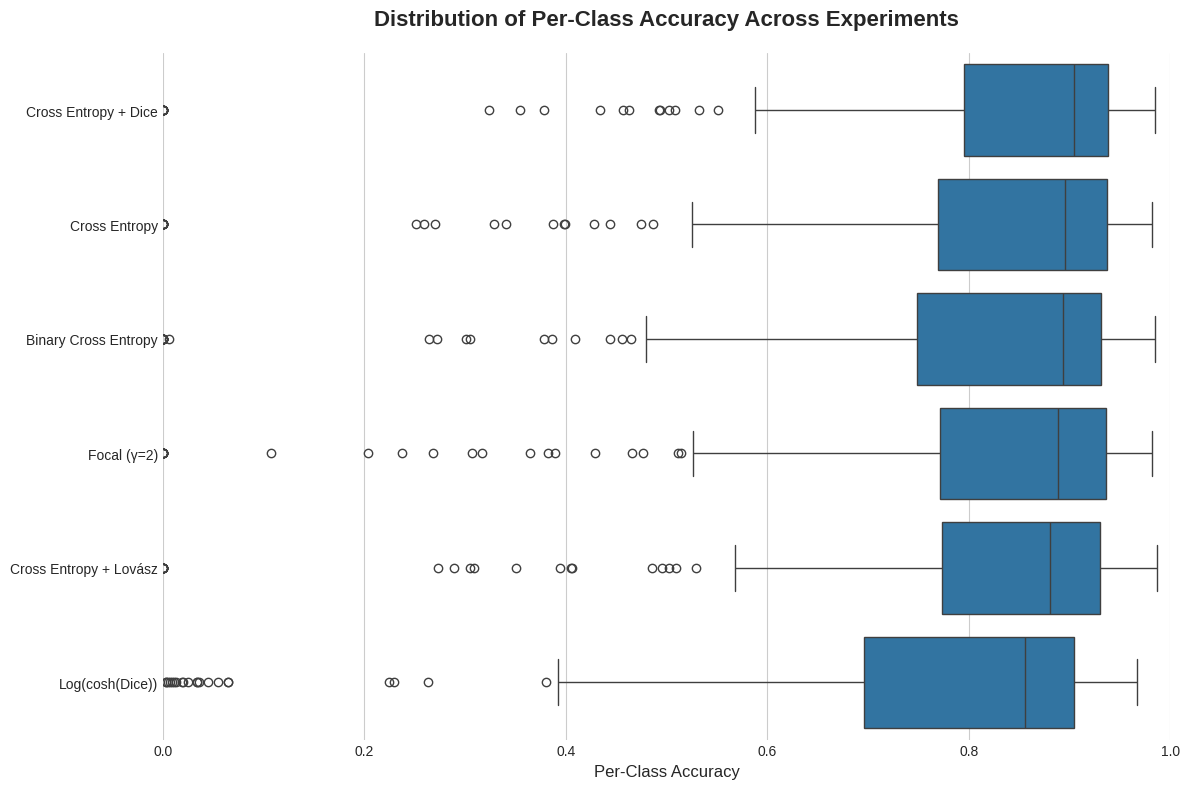

In [75]:
def plot_accuracy_distribution(df: pd.DataFrame):
    df = df.copy()
    df["run_name"] = df["run_name"].map(HUMAN_READABLE_NAMES).fillna(df["run_name"])
    # 1. Filter for run_name and all per-class accuracy columns
    # This selects all columns that start with 'acc_'
    acc_cols = [col for col in df.columns if col.startswith('acc_')]
    if not acc_cols:
        raise ValueError("No per-class accuracy columns (starting with 'acc_') found in the DataFrame.")
        
    df_acc = df[['run_name'] + acc_cols]

    # 2. Reshape the data from a wide to a long format
    # This is the ideal format for plotting with seaborn
    df_long = df_acc.melt(id_vars=['run_name'], var_name='class', value_name='accuracy')

    # 3. Set plot style and create the figure
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(12, 8))

    # 4. Determine the order for plotting
    # This sorts the experiments by their median accuracy, making the chart easier to read.
    sorted_order = df_long.groupby('run_name')['accuracy'].median().sort_values(ascending=False).index

    # 5. Create the box plot
    sns.boxplot(
        data=df_long,
        x='accuracy',
        y='run_name',
        order=sorted_order,
        orient='h',  # Horizontal plot
        ax=ax
    )

    # 6. Customize the plot for clarity and professionalism
    ax.set_title('Distribution of Per-Class Accuracy Across Experiments', fontsize=16, weight='bold', pad=20)
    ax.set_xlabel('Per-Class Accuracy', fontsize=12)
    ax.set_ylabel('') # Y-axis labels are the experiment names, so no title is needed
    ax.set_xlim(0, 1) # Accuracy scores are between 0 and 1

    # Remove distracting chart borders
    sns.despine(left=True, bottom=True)
    
    plt.tight_layout()
    
    # Save the figure to a file
    plt.savefig(os.path.join(FIG_DIR, "per_class_accuracy_distribution.png"), dpi=300)
    print("Plot saved to per_class_accuracy_distribution.png")

    plt.show()

plot_accuracy_distribution(R_overall)

Plot saved to per_class_accuracy_delta.png


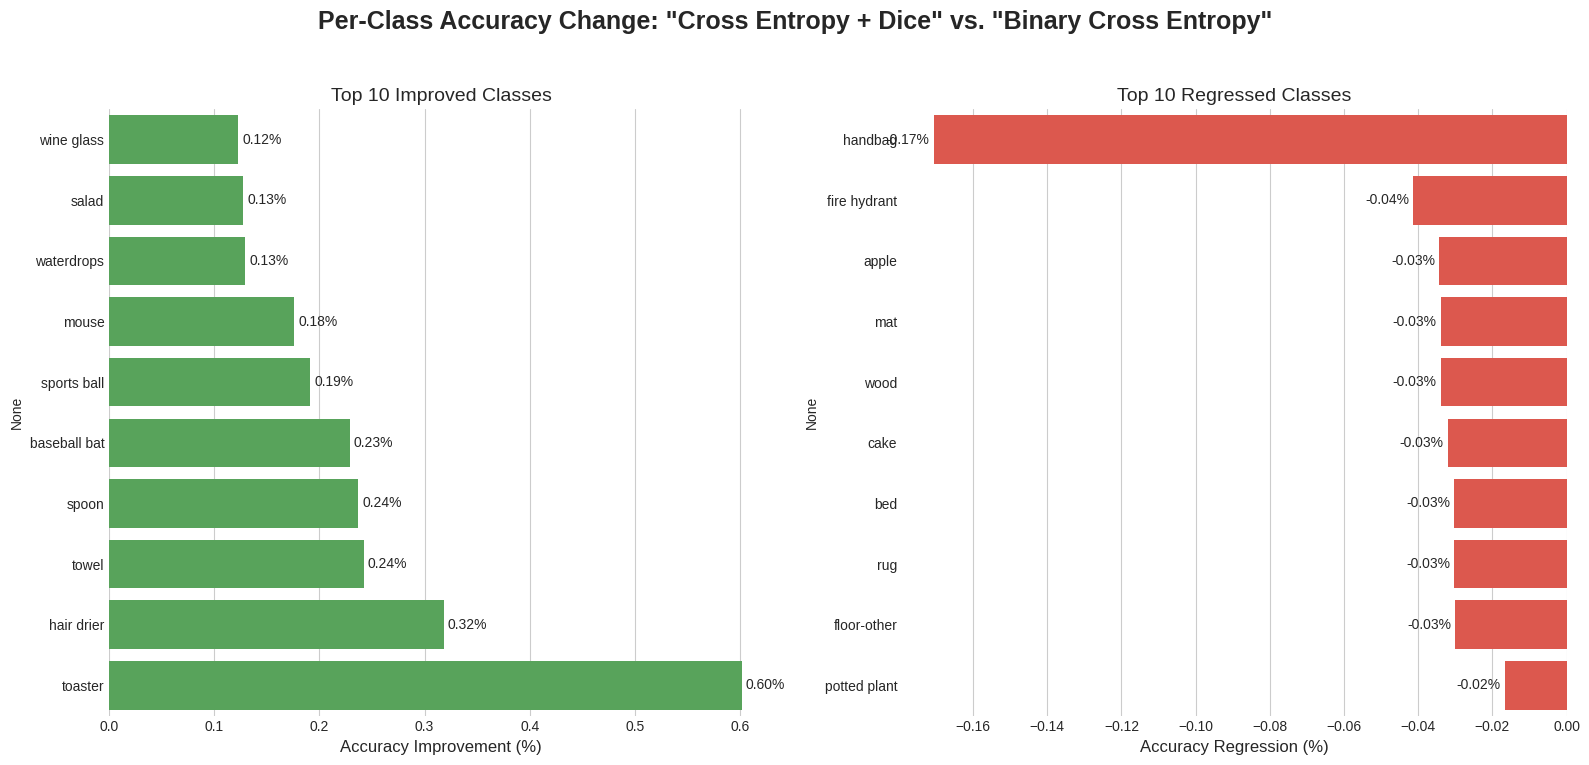

In [76]:
def plot_accuracy_delta(df: pd.DataFrame, best_experiment_name: str, baseline_experiment_name: str, top_n: int = 10):
    df = df.copy()

    # 1. Isolate accuracy columns and the two experiments of interest
    acc_cols = [col for col in df.columns if col.startswith('acc_')]
    df_compare = df[df['run_name'].isin([best_experiment_name, baseline_experiment_name])].copy()
    
    if len(df_compare) != 2:
        raise ValueError("Could not find both specified experiments in the DataFrame.")

    df["run_name"] = df["run_name"].map(HUMAN_READABLE_NAMES).fillna(df["run_name"])

    # 2. Calculate the delta
    # Set run_name as index to easily select rows, then select only acc columns
    df_compare.set_index('run_name', inplace=True)
    baseline_acc = df_compare.loc[baseline_experiment_name, acc_cols]
    best_acc = df_compare.loc[best_experiment_name, acc_cols]
    
    # Subtract baseline from best to get the improvement delta
    delta = best_acc - baseline_acc
    delta.name = "accuracy_change" # Name the series for easier plotting
    
    # Remove the 'acc_' prefix from class names for cleaner labels
    delta.index = delta.index.str.replace('acc_', '')
    
    # 3. Get Top N winners and losers
    delta = delta.sort_values(ascending=False)
    winners = delta.head(top_n).sort_values(ascending=True) # Ascending for horizontal plot
    losers = delta.tail(top_n).sort_values(ascending=True) # Ascending for horizontal plot

    # 4. Create the plot with two subplots
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))
    fig.suptitle(f'Per-Class Accuracy Change: "{HUMAN_READABLE_NAMES[best_experiment_name]}" vs. "{HUMAN_READABLE_NAMES[baseline_experiment_name]}"', fontsize=18, weight='bold')

    # Plot for "Biggest Winners"
    sns.barplot(x=winners.values, y=winners.index, ax=ax1, color='#4CAF50', orient='h')
    ax1.set_title(f'Top {top_n} Improved Classes', fontsize=14)
    ax1.set_xlabel('Accuracy Improvement (%)', fontsize=12)
    ax1.bar_label(ax1.containers[0], fmt='%.2f%%', padding=3) # Show percentage change
    
    # Plot for "Biggest Losers"
    sns.barplot(x=losers.values, y=losers.index, ax=ax2, color='#F44336', orient='h')
    ax2.set_title(f'Top {top_n} Regressed Classes', fontsize=14)
    ax2.set_xlabel('Accuracy Regression (%)', fontsize=12)
    ax2.bar_label(ax2.containers[0], fmt='%.2f%%', padding=3) # Show percentage change

    # 5. Final customization and saving
    sns.despine(left=True, bottom=True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to make room for suptitle
    
    plt.savefig(os.path.join(FIG_DIR, "per_class_accuracy_delta.png"), dpi=300)
    print("Plot saved to per_class_accuracy_delta.png")
    plt.show()

BASELINE = "coco_segmentation_bce_loss"
BEST = "coco_segmentation_ce_dice_loss"
plot_accuracy_delta(R_overall, BEST, BASELINE, top_n=10)


In [72]:
with open("analysis/pixel_level_distribution.json", "r") as f:
    data = json.load(f)
labels = data["labels"]
train_class_counts = np.array(data["train"]["class_counts"])
train_total_pixels = data["train"]["total_pixels"]
val_class_counts = np.array(data["validation"]["class_counts"])
val_total_pixels = data["validation"]["total_pixels"]

# columns are the labels
# rows are train and validation counts
counts_df = pd.DataFrame({
    "label": labels,
    "train_count": train_class_counts,
    "val_count": val_class_counts,
})
counts_df["train_percentage"] = counts_df["train_count"] / train_total_pixels * 100
counts_df["val_percentage"] = counts_df["val_count"] / val_total_pixels * 100
counts_df = counts_df.sort_values(by="train_percentage", ascending=False)
counts_df

,label,train_count,val_count,train_percentage,val_percentage
1,person,803179764,31037131,10.360860,9.471781
157,sky-other,405610075,17968188,5.232290,5.483456
0,unlabeled,391457456,11500882,5.049724,3.509791
169,tree,383634755,16382390,4.948812,4.999509
172,wall-concrete,282073854,13095093,3.638697,3.996305
...,...,...,...,...,...
91,hair brush,727914,30781,0.009390,0.009394
69,desk,703265,27842,0.009072,0.008497
71,door,702044,28855,0.009056,0.008806
68,window,698800,29762,0.009014,0.009083


Plot saved to per_class_accuracy_delta_sorted_by_frequency.png


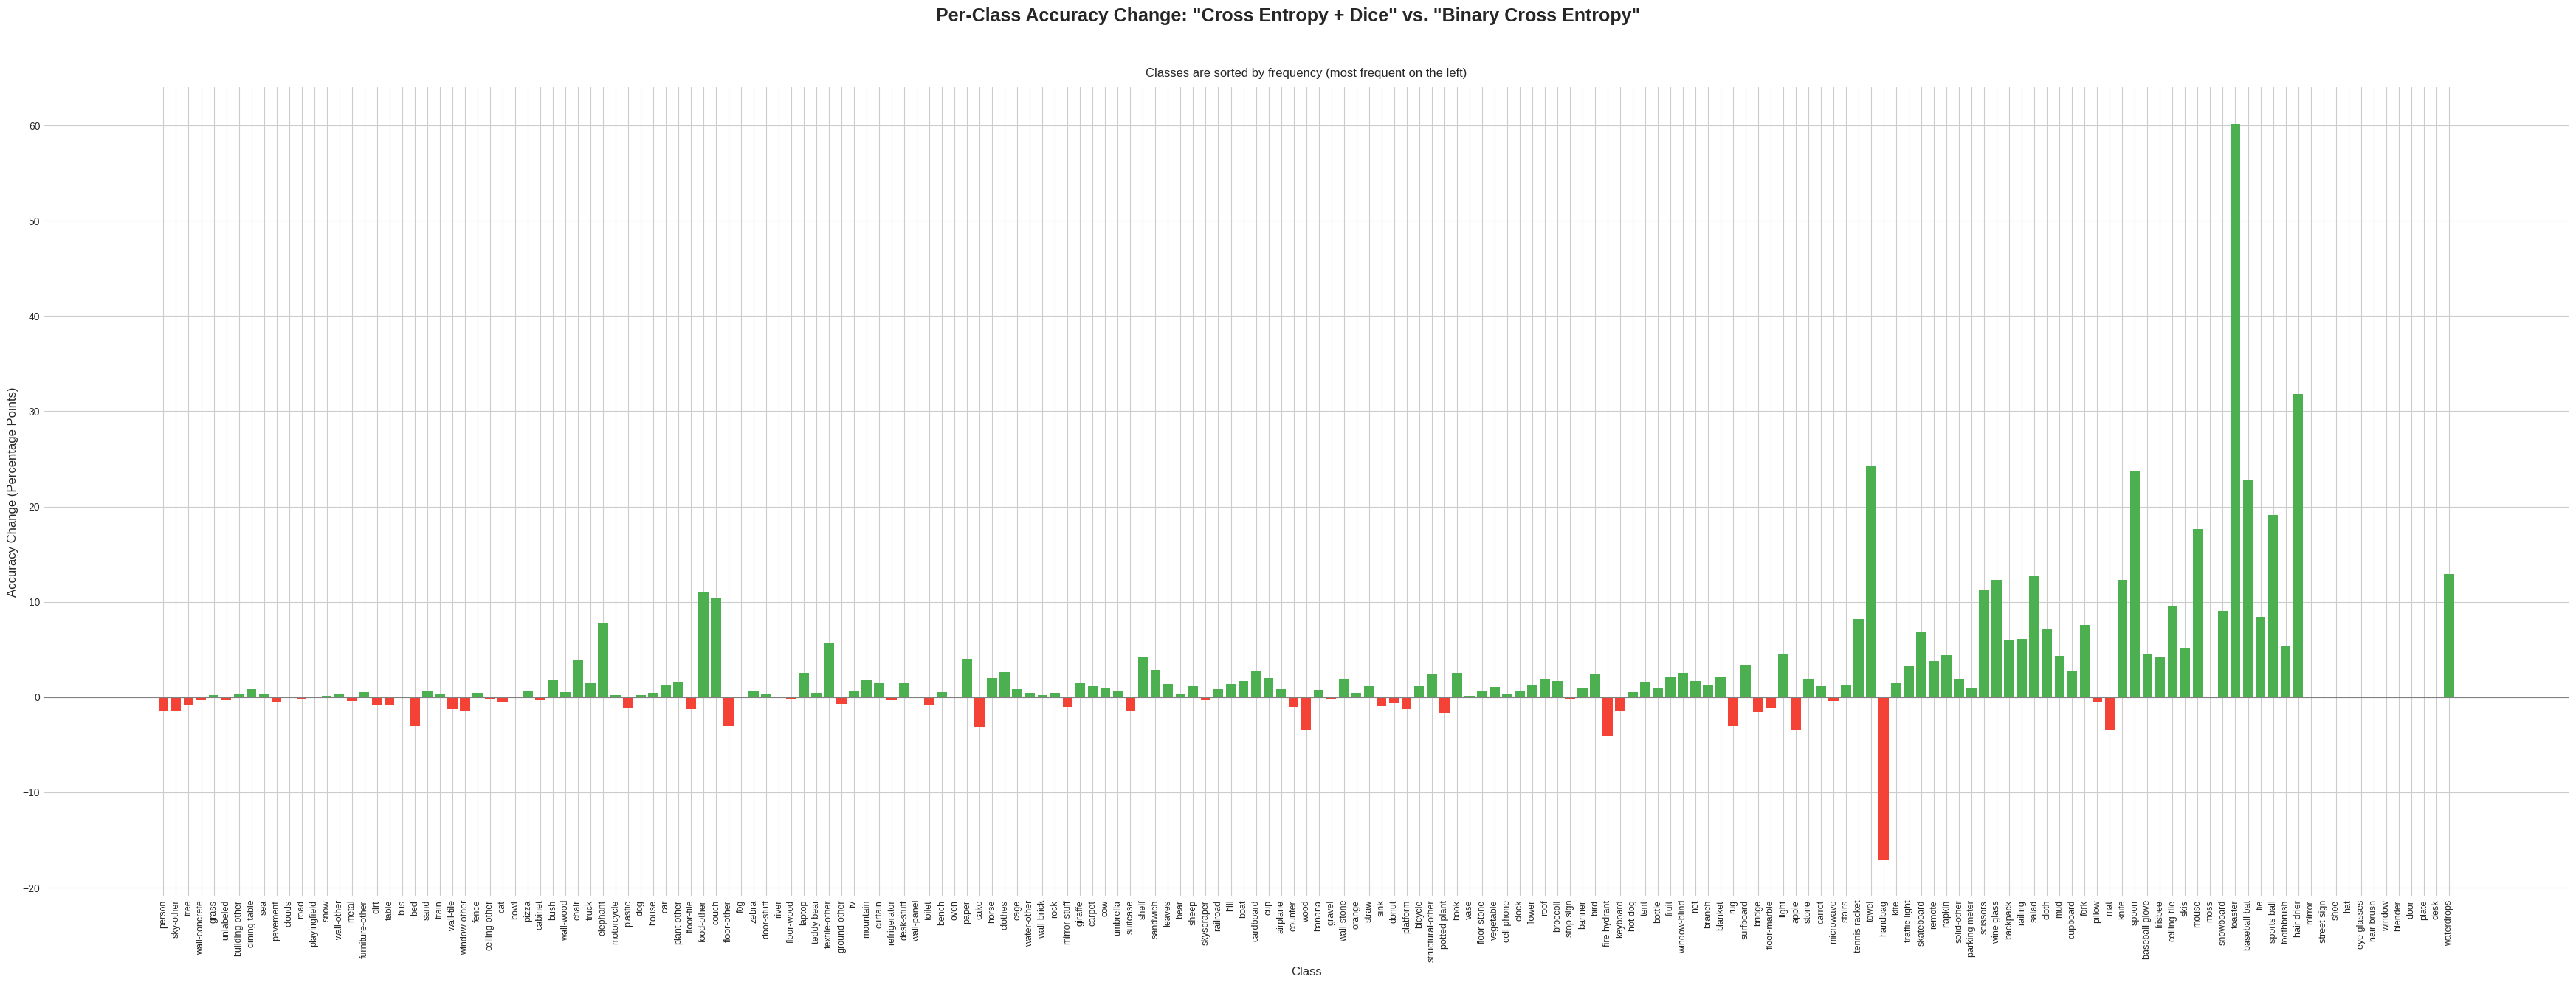

/tmp/ipykernel_20407/724216014.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot saved to class_distribution_val_percentage.png


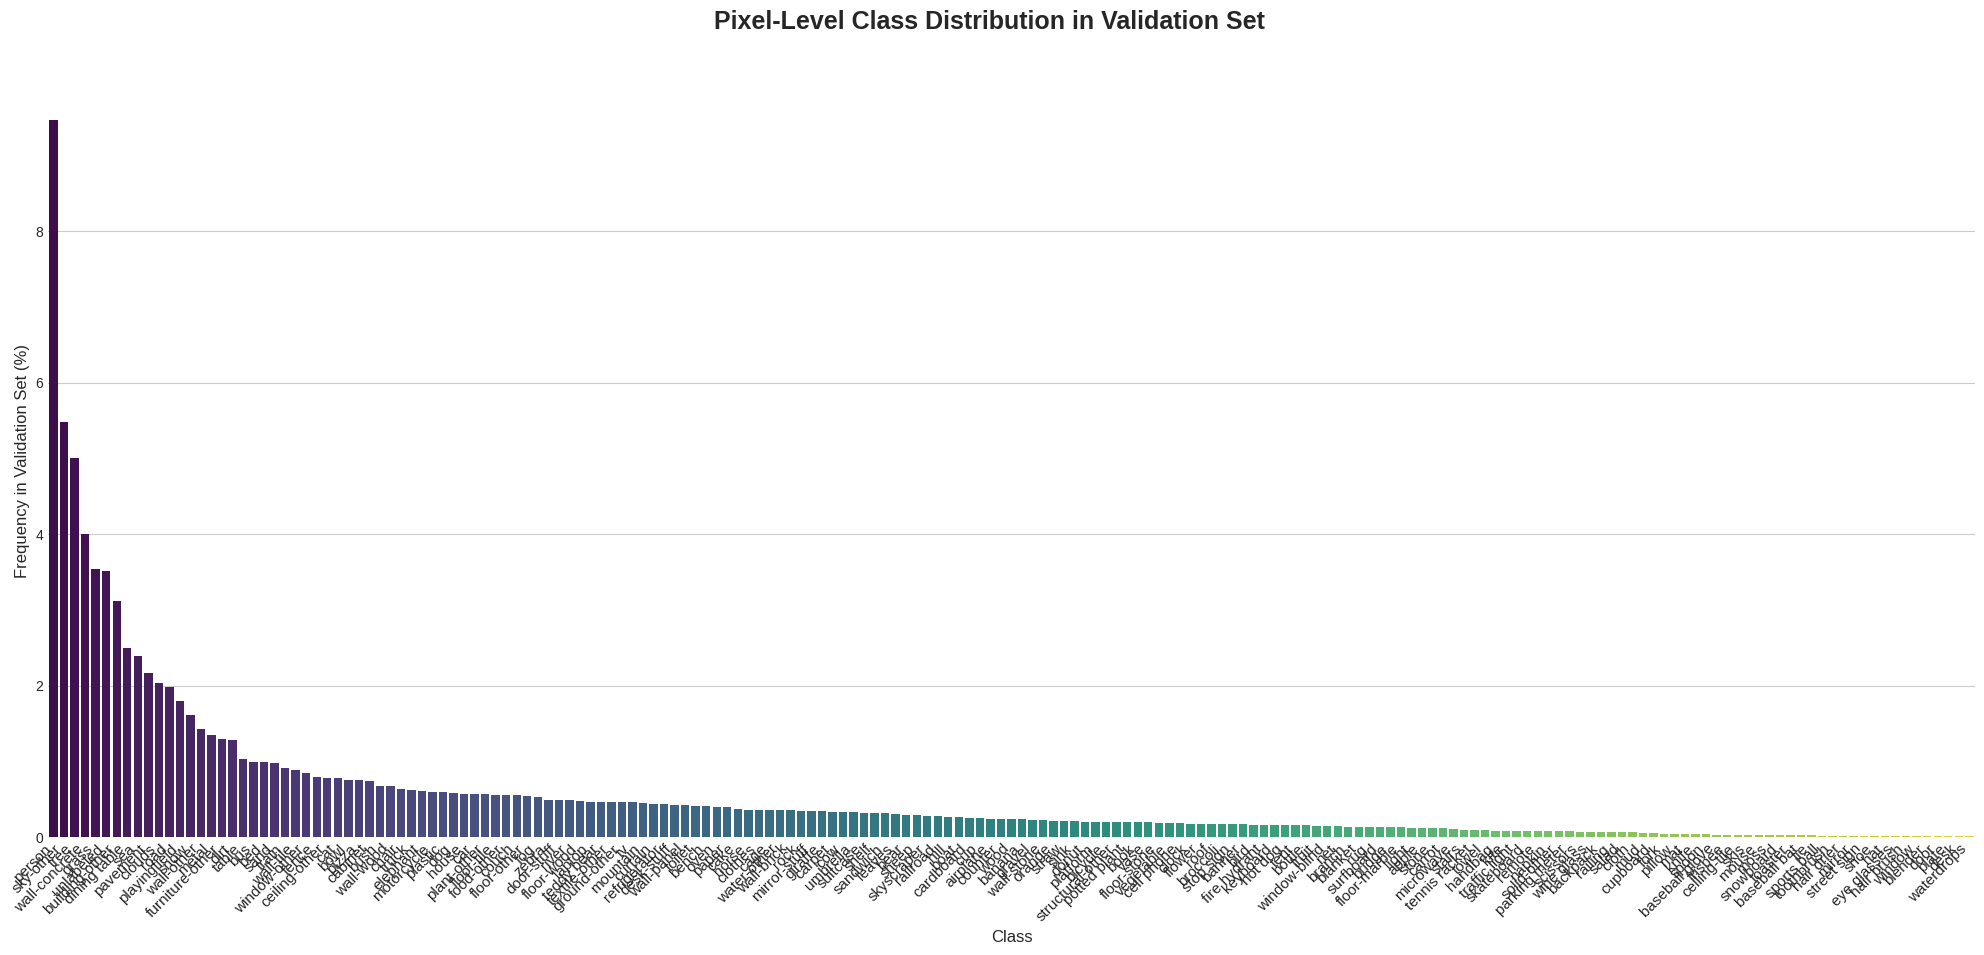

/tmp/ipykernel_20407/724216014.py:80: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


Plot saved to class_distribution_train_percentage.png


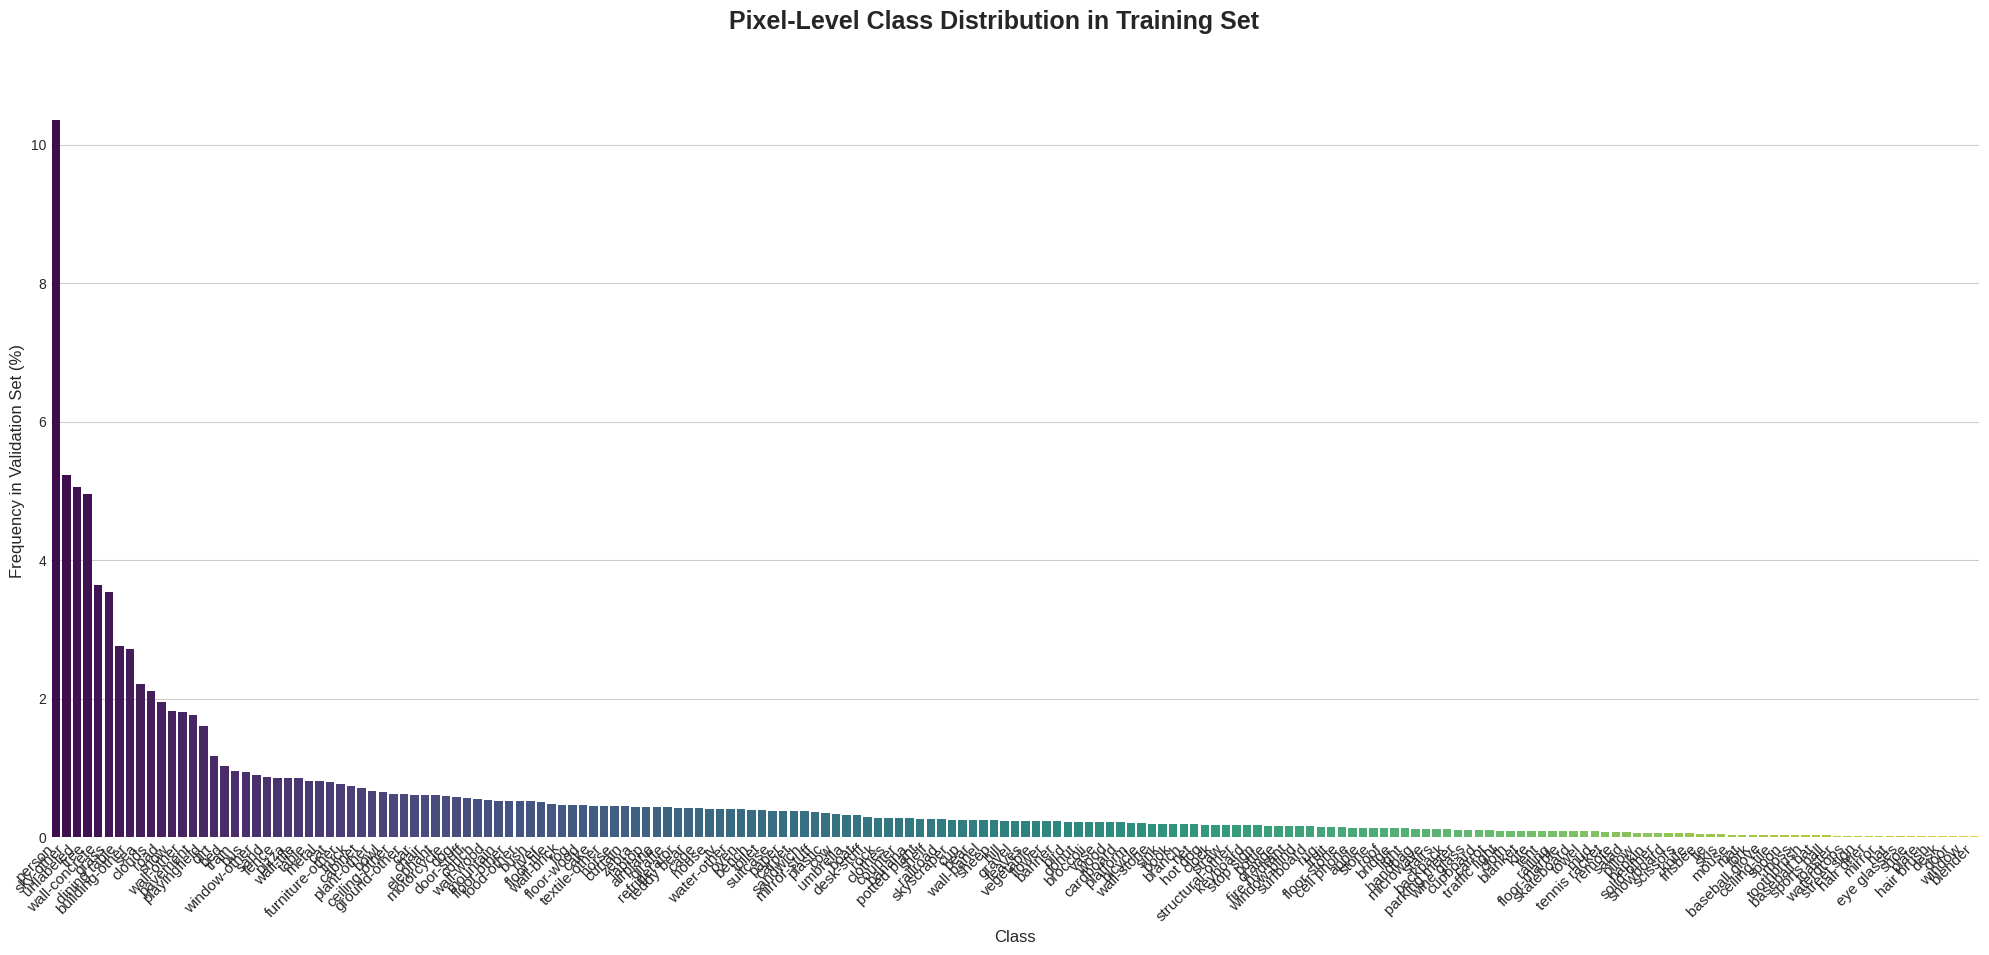

In [89]:
def plot_accuracy_delta(df: pd.DataFrame, counts_df: pd.DataFrame, best_experiment_name: str, baseline_experiment_name: str):
    """
    Generates a bar chart showing the change (delta) in per-class accuracy between
    a 'best' and 'baseline' experiment, with classes sorted by their frequency.

    Args:
        df: A pandas DataFrame with a 'run_name' column and 'acc_...' columns.
        counts_df: DataFrame with class frequency ('label', 'val_percentage').
        best_experiment_name: The name of the run_name to be considered the 'best'.
        baseline_experiment_name: The name of the run_name to use as a baseline.
    """
    # 1. Isolate accuracy columns and the two experiments of interest
    acc_cols = [col for col in df.columns if col.startswith('acc_')]
    df_compare = df[df['run_name'].isin([best_experiment_name, baseline_experiment_name])].copy()

    if len(df_compare) != 2:
        raise ValueError("Could not find both specified experiments in the DataFrame.")

    # 2. Calculate the delta in percentage points
    df_compare.set_index('run_name', inplace=True)
    baseline_acc = df_compare.loc[baseline_experiment_name, acc_cols]
    best_acc = df_compare.loc[best_experiment_name, acc_cols]
    delta = (best_acc - baseline_acc) * 100  # Convert to percentage points
    delta.name = "accuracy_change"
    delta.index = delta.index.str.replace('acc_', '')

    # 3. Merge with counts_df and sort by validation set frequency
    delta_df = delta.to_frame().reset_index().rename(columns={'index': 'label'})
    merged_df = pd.merge(delta_df, counts_df[['label', 'val_percentage']], on='label')
    
    # Sort by frequency. ascending=False places the most frequent classes on the left.
    sorted_df = merged_df.sort_values(by="val_percentage", ascending=False)

    # 4. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid')
    # The figure needs to be very wide to accommodate all classes
    fig, ax = plt.subplots(figsize=(35, 14))
    fig.suptitle(f'Per-Class Accuracy Change: "{HUMAN_READABLE_NAMES[best_experiment_name]}" vs. "{HUMAN_READABLE_NAMES[baseline_experiment_name]}"', fontsize=18, weight='bold')

    # Assign colors based on positive (improvement) or negative (regression) change
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in sorted_df['accuracy_change']]

    # Create the vertical bar plot
    ax.bar(sorted_df['label'], sorted_df['accuracy_change'], color=colors)

    # 5. Final customization and saving
    ax.set_title('Classes are sorted by frequency (most frequent on the left)', fontsize=12, pad=10)
    ax.set_ylabel('Accuracy Change (Percentage Points)', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    ax.axhline(0, color='grey', linewidth=0.8) # Add a line at zero for reference
    plt.xticks(rotation=90) # Rotate x-axis labels
    ax.tick_params(axis='x', labelsize=9) # Adjust font size for readability
    
    sns.despine(left=True, bottom=True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96]) # Adjust layout for suptitle

    plt.savefig(os.path.join(FIG_DIR, "per_class_accuracy_delta_sorted_by_frequency.png"), dpi=300)
    print("Plot saved to per_class_accuracy_delta_sorted_by_frequency.png")
    plt.show()

def plot_class_distribution(counts_df: pd.DataFrame, top_n: int = 30, set_="Validation", by="val_percentage"):
    """
    Generates a bar chart showing the distribution of the most frequent classes.

    Args:
        counts_df: DataFrame with class frequency ('label', 'val_percentage').
        top_n: The number of top classes to display.
    """
    # 1. Sort by validation set frequency and select top N
    sorted_counts = counts_df.sort_values(by=by, ascending=False).head(top_n)

    # 2. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(20, 10))
    if top_n is None:
        fig.suptitle(f'Pixel-Level Class Distribution in {set_} Set', fontsize=18, weight='bold')
    else:
        fig.suptitle(f'Pixel-Level Class Distribution of Top {top_n} Most Frequent Classes in {set_} Set', fontsize=18, weight='bold')

    sns.barplot(
        x='label',
        y=by,
        data=sorted_counts,
        ax=ax,
        palette='viridis'
    )

    # 3. Final customization and saving
    ax.set_ylabel('Frequency in Validation Set (%)', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better fit
    ax.tick_params(axis='x', labelsize=11)
    
    sns.despine(left=True, bottom=True)
    plt.tight_layout(rect=[0, 0.03, 1, 0.96])

    plt.savefig(os.path.join(FIG_DIR, f"class_distribution_{by}.png"), dpi=300)
    print(f"Plot saved to class_distribution_{by}.png")
    plt.show()

plot_accuracy_delta(R_overall, counts_df, BEST, BASELINE)
plot_class_distribution(counts_df, top_n=None, by="val_percentage", set_="Validation")
plot_class_distribution(counts_df, top_n=None, by="train_percentage", set_="Training")

Plot saved to accuracy_delta_vs_distribution.png


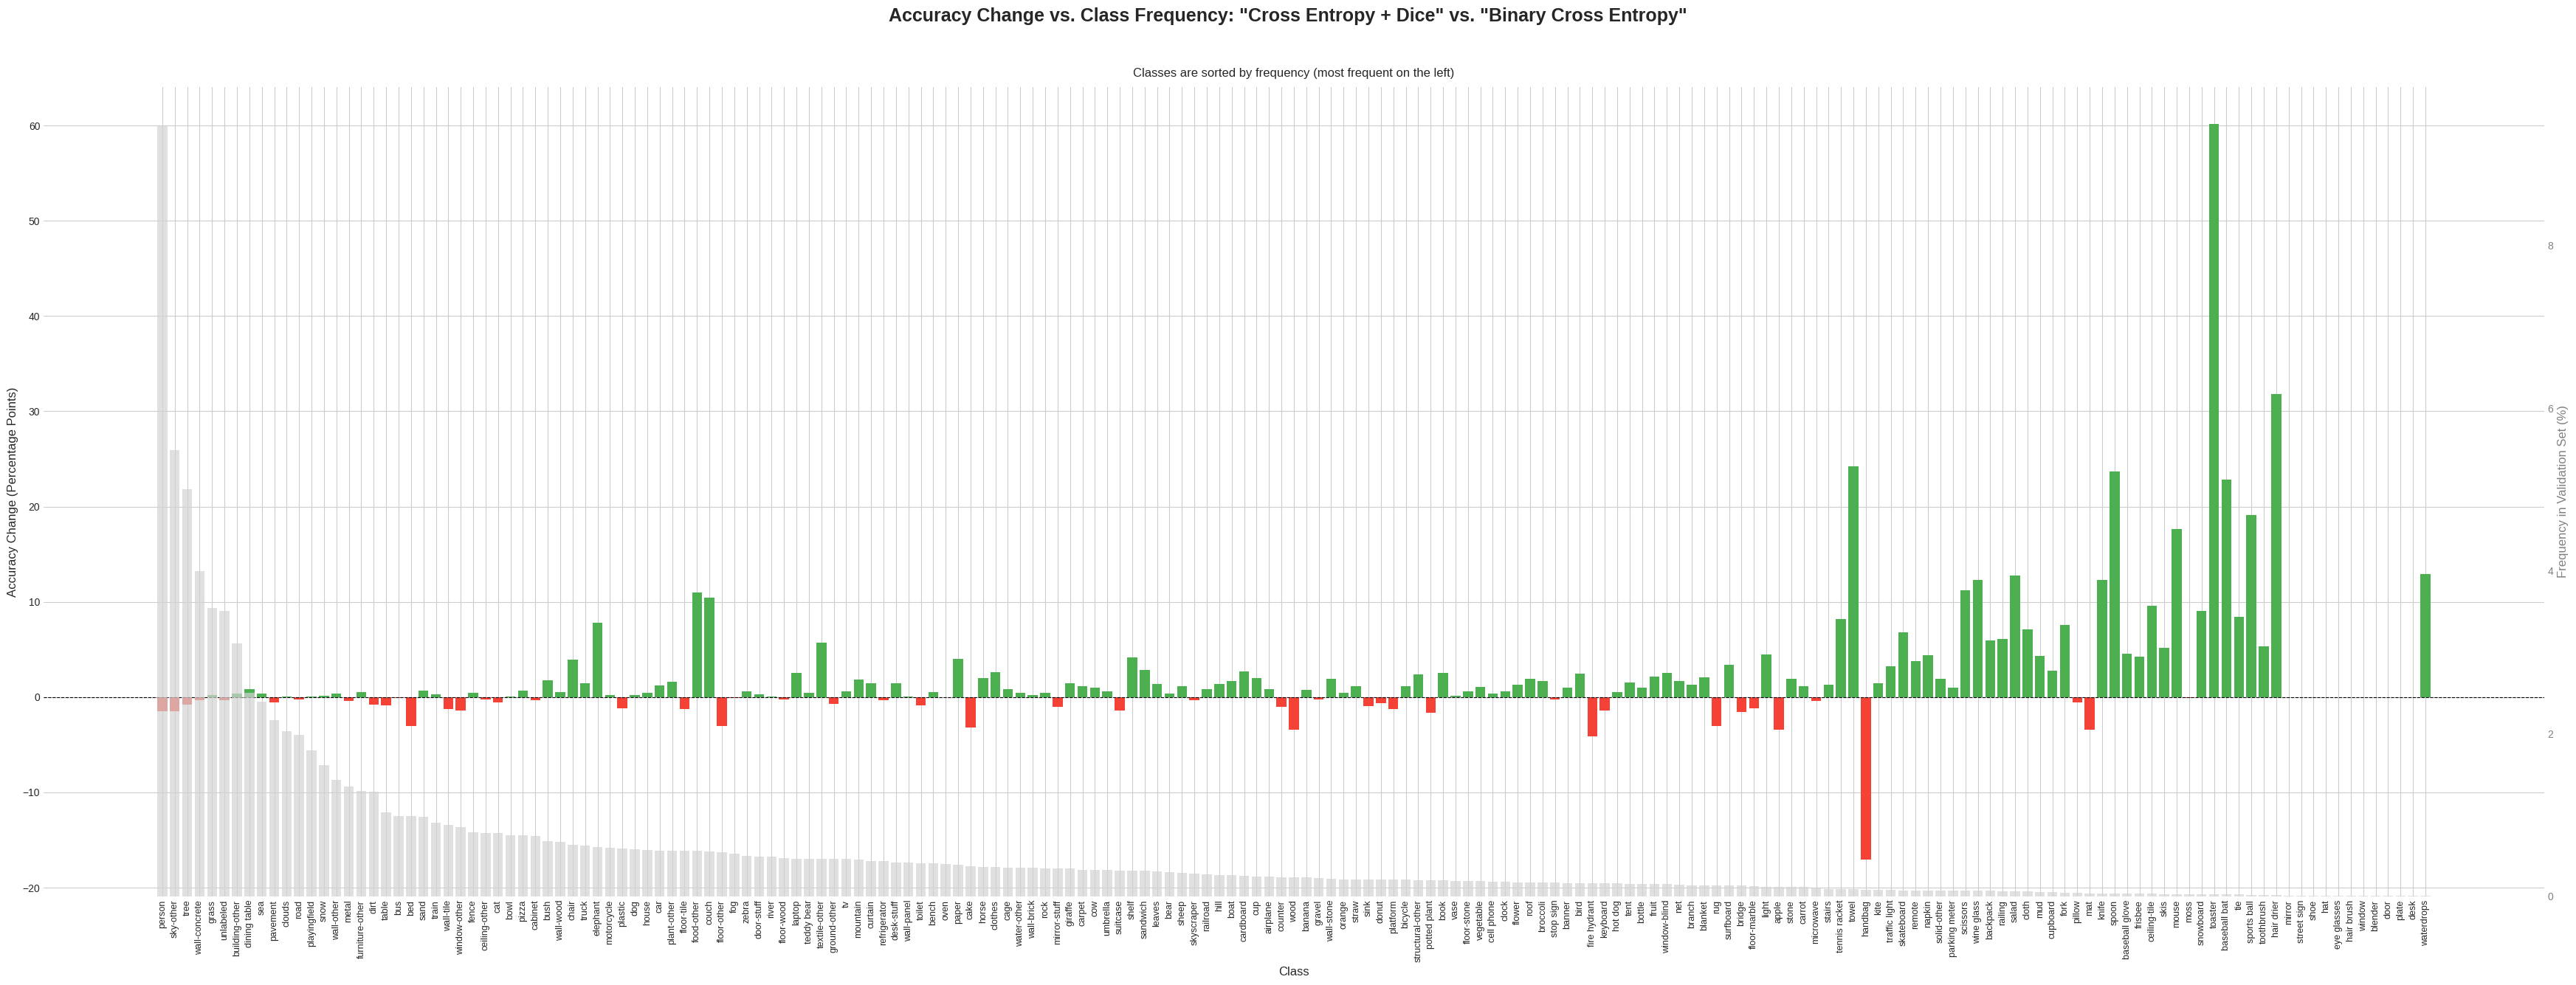

In [86]:
def plot_accuracy_delta_overlay(df: pd.DataFrame, counts_df: pd.DataFrame, best_experiment_name: str, baseline_experiment_name: str):
    """
    Generates a bar chart showing the change (delta) in per-class accuracy between
    a 'best' and 'baseline' experiment, overlaying the class frequency distribution.

    Args:
        df: A pandas DataFrame with a 'run_name' column and 'acc_...' columns.
        counts_df: DataFrame with class frequency ('label', 'val_percentage').
        best_experiment_name: The name of the run_name to be considered the 'best'.
        baseline_experiment_name: The name of the run_name to use as a baseline.
    """
    # 1. Isolate accuracy columns and the two experiments of interest
    acc_cols = [col for col in df.columns if col.startswith('acc_')]
    df_compare = df[df['run_name'].isin([best_experiment_name, baseline_experiment_name])].copy()

    if len(df_compare) != 2:
        raise ValueError("Could not find both specified experiments in the DataFrame.")

    # 2. Calculate the delta in percentage points
    df_compare.set_index('run_name', inplace=True)
    baseline_acc = df_compare.loc[baseline_experiment_name, acc_cols]
    best_acc = df_compare.loc[best_experiment_name, acc_cols]
    delta = (best_acc - baseline_acc) * 100  # Convert to percentage points
    delta.name = "accuracy_change"
    delta.index = delta.index.str.replace('acc_', '')

    # 3. Merge with counts_df and sort by validation set frequency
    delta_df = delta.to_frame().reset_index().rename(columns={'index': 'label'})
    merged_df = pd.merge(delta_df, counts_df[['label', 'val_percentage']], on='label')
    sorted_df = merged_df.sort_values(by="val_percentage", ascending=False)

    # 4. Create the plot
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, ax = plt.subplots(figsize=(35, 14))
    fig.suptitle(f'Accuracy Change vs. Class Frequency: "{HUMAN_READABLE_NAMES[best_experiment_name]}" vs. "{HUMAN_READABLE_NAMES[baseline_experiment_name]}"', fontsize=18, weight='bold')

    # --- Create the second y-axis for the distribution ---
    ax2 = ax.twinx()

    # --- Plot the class distribution on the background axis (ax2) ---
    sns.barplot(x='label', y='val_percentage', data=sorted_df, ax=ax2, color='lightgray', alpha=0.7)
    ax2.set_ylabel('Frequency in Validation Set (%)', fontsize=12, color='gray')
    ax2.tick_params(axis='y', labelcolor='gray')
    ax2.grid(False)

    # --- Plot the accuracy delta on the foreground axis (ax) ---
    colors = ['#4CAF50' if v >= 0 else '#F44336' for v in sorted_df['accuracy_change']]
    ax.bar(sorted_df['label'], sorted_df['accuracy_change'], color=colors)
    ax.patch.set_visible(False) # Make ax transparent to see ax2

    # 5. Final customization and saving
    ax.set_title('Classes are sorted by frequency (most frequent on the left)', fontsize=12, pad=10)
    ax.set_ylabel('Accuracy Change (Percentage Points)', fontsize=12)
    ax.set_xlabel('Class', fontsize=12)
    ax.axhline(0, color='k', linewidth=0.8, linestyle='--')
    ax.tick_params(axis='x', rotation=90, labelsize=9)
    
    sns.despine(left=True, bottom=True) # Despine the main axis
    ax2.spines['right'].set_color('gray')

    plt.tight_layout(rect=[0, 0.03, 1, 0.96])
    plt.savefig(os.path.join(FIG_DIR, "accuracy_delta_vs_distribution.png"), dpi=300)
    print("Plot saved to accuracy_delta_vs_distribution.png")
    plt.show()

plot_accuracy_delta_overlay(R_overall, counts_df, BEST, BASELINE)